# Lab Day 1 — Forest CoverType
Notebook hoàn chỉnh Part 0–4. Mở trên Colab, bật GPU và chạy theo thứ tự.

**Chuẩn bị Colab:** upload toàn bộ dự án hiện tại vào
`MyDrive/Labs/K4-Track4-Day1-Neuralnetwork`. Cell đầu tự mount Drive.
Nếu dùng vị trí khác, sửa `COLAB_REPO` bên dưới. Không chỉ upload notebook:
notebook cần các module `.py`, dữ liệu, scripts và template Excel.

Mặc định: 20 epoch mỗi thí nghiệm, baseline 3 seed và 7 nhóm thí nghiệm.
`SMOKE = True` chỉ kiểm tra chương trình với ít mẫu/epoch, không dùng số liệu đó
cho báo cáo. Kết quả kiểm tra nằm riêng trong `_smoke/`.

Notebook tự lưu JSON/PNG/Excel trên Drive. Hãy lưu bản notebook có output vào
`submission_2A202602941/code/lab.ipynb`. Các kết quả cũ sẽ được thay bằng lượt chạy
mới có cùng `exp_id`. Không chọn lại cấu hình sau khi xem điểm eval.

In [9]:
from pathlib import Path
import os, sys, json, subprocess

COLAB_REPO = "/content/drive/MyDrive/Day1"
MSSV = "2A202602941"
SMOKE = os.environ.get("LAB_SMOKE", "0") == "1"

IN_COLAB = "google.colab" in sys.modules or bool(os.environ.get("COLAB_RELEASE_TAG"))
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_ROOT = Path(os.environ.get("LAB_REPO_ROOT", COLAB_REPO)).resolve()
else:
    candidates = [Path.cwd(), *Path.cwd().parents]
    REPO_ROOT = next((p for p in candidates if (p / "scripts/split_data.py").exists()), None)
    if REPO_ROOT is None:
        raise FileNotFoundError("Mở notebook từ thư mục dự án hoặc đặt LAB_REPO_ROOT")
    REPO_ROOT = Path(os.environ.get("LAB_REPO_ROOT", str(REPO_ROOT))).resolve()

CODE_DIR = REPO_ROOT / f"submission_{MSSV}" / "code"
if not CODE_DIR.exists():
    CODE_DIR = REPO_ROOT / "code"
assert (CODE_DIR / "lab_workflow.py").exists(), f"Thiếu code hoàn chỉnh tại {CODE_DIR}"
OUT_DIR = Path(os.environ.get("LAB_OUTPUT_DIR", str(REPO_ROOT / f"submission_{MSSV}"))).resolve()
if SMOKE and "LAB_OUTPUT_DIR" not in os.environ:
    OUT_DIR = OUT_DIR / "_smoke"
os.chdir(CODE_DIR)
sys.path.insert(0, str(CODE_DIR))
for name in ("figures", "results"):
    (OUT_DIR / name).mkdir(parents=True, exist_ok=True)

import importlib.util
packages = {"numpy": "numpy", "pandas": "pandas", "sklearn": "scikit-learn",
            "matplotlib": "matplotlib", "openpyxl": "openpyxl", "torch": "torch"}
missing = [pkg for mod, pkg in packages.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)

import numpy as np
import pandas as pd
import torch
from IPython.display import display
from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, activation_stats
from train import DEFAULT_CFG, set_seed, evaluate, run_experiment
from health_checks import run_health_checks
from lab_workflow import (run_logged, select_by_val, seed_statistics,
                          summarize_runs, score_final, export_table)

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    torch.set_num_threads(min(4, torch.get_num_threads()))
print("PyTorch:", torch.__version__, "| Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Repo:", REPO_ROOT, "| Output:", OUT_DIR, "| SMOKE:", SMOKE)
EPOCHS = 1 if SMOKE else 20
all_results = []

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu130 | Device: cuda
GPU: Tesla T4
Repo: /content/drive/MyDrive/Day1 | Output: /content/drive/MyDrive/Day1/submission_2A202602941 | SMOKE: False


## Part 0 — Dữ liệu
Chia train/eval bằng metadata đã cho; tách validation 20%, stratify và seed 42.
Chỉ fit chuẩn hoá 10 cột liên tục trên phần train còn lại; giữ 44 cột one-hot.
Tập eval được biến đổi bằng cùng thống kê train và chỉ dùng để chấm cuối.

In [10]:
processed = REPO_ROOT / "data/processed"
if not all((processed / f"{name}.npz").exists() for name in ("train", "eval")):
    subprocess.run([sys.executable, str(REPO_ROOT / "scripts/split_data.py")],
                   cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=str(processed))
expected = {"X_tr": (371847, 54), "X_val": (92962, 54), "X_eval": (116203, 54)}
for key, shape in expected.items():
    print(key, tuple(data[key].shape), data[key].dtype)
    assert tuple(data[key].shape) == shape
numeric = data["X_tr"][:, :10]
print("Numeric mean:", numeric.mean(0).cpu().numpy())
print("Numeric std:", numeric.std(0, unbiased=False).cpu().numpy())
assert torch.allclose(numeric.mean(0), torch.zeros(10, device=device), atol=1e-4)
assert torch.allclose(numeric.std(0, unbiased=False), torch.ones(10, device=device), atol=1e-4)
for key in ("y_tr", "y_val", "y_eval"):
    print(key, (torch.bincount(data[key], minlength=7).float() / len(data[key])).cpu().numpy())

Split sizes: train=371847, val=92962, eval=116203
Majority-class validation accuracy: 0.4876
X_tr (371847, 54) torch.float32
X_val (92962, 54) torch.float32
X_eval (116203, 54) torch.float32
Numeric mean: [ 1.0176711e-08 -8.2070251e-10  8.9456575e-09 -7.7966744e-09
 -1.5388173e-09  1.1859152e-08 -8.2890956e-09  4.5959343e-09
 -2.0517563e-09  3.6110912e-09]
Numeric std: [1.         0.9999999  0.99999994 1.         0.99999994 1.
 1.         0.99999994 1.         0.99999994]
y_tr [0.36460695 0.4875984  0.06153606 0.00473044 0.01633736 0.02989133
 0.03529947]
y_val [0.36460057 0.48759708 0.06154127 0.00472236 0.01634001 0.02989393
 0.03530475]
y_eval [0.3646033  0.48760357 0.06153886 0.00472449 0.01634209 0.02988735
 0.03530029]


## Part 1 — Kiểm tra model và backprop
Kiểm tra số tham số, shape qua từng lớp, loss bước 0, gradient và học thuộc 20 mẫu.
`ln(7)` là loss dự đoán đồng đều; He có thể tạo logits không đồng đều nên
không ép loss phải bằng chính xác mốc này. Phép học thuộc dùng model riêng.

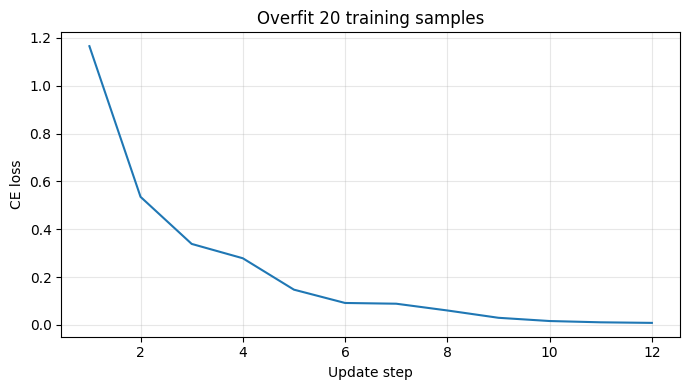

{
  "seed": 1,
  "parameters": 47879,
  "shape_trace": [
    {
      "layer": "Linear",
      "shape": [
        8,
        256
      ]
    },
    {
      "layer": "ReLU",
      "shape": [
        8,
        256
      ]
    },
    {
      "layer": "Dropout",
      "shape": [
        8,
        256
      ]
    },
    {
      "layer": "Linear",
      "shape": [
        8,
        128
      ]
    },
    {
      "layer": "ReLU",
      "shape": [
        8,
        128
      ]
    },
    {
      "layer": "Dropout",
      "shape": [
        8,
        128
      ]
    },
    {
      "layer": "Linear",
      "shape": [
        8,
        7
      ]
    }
  ],
  "step0_loss": 2.2690618094036408,
  "uniform_ce": 1.9459101490553132,
  "activation_std": [
    0.709928572177887,
    0.6975852847099304,
    0.6183176040649414
  ],
  "gradient_norms": {
    "net.0.weight": 0.9022008776664734,
    "net.0.bias": 0.39315465092658997,
    "net.3.weight": 2.77693247795105,
    "net.3.bias": 0.5370684862136

In [11]:
health = run_health_checks(data, OUT_DIR, device=device, seed=1, show_plot=True)

## Part 2 — Baseline và độ nhiễu
**Dự đoán trước:** SGD momentum với learning rate vừa phải sẽ giảm loss;
lr quá thấp học chậm, quá cao có thể dao động. Chọn lr bằng val macro-F1
tại epoch có val loss thấp nhất, không dùng eval. Mỗi lr chạy cùng số epoch.

Baseline: M-base, He, CE, SGD momentum 0.9, batch 512, FP32, không dropout/clip.
Sau khi chọn lr, chạy baseline seed 1, 2, 3; so sánh kỹ thuật với seed 1.

In [12]:
# Smoke uses stratified subsets but leaves the complete eval untouched.
training_data = {k: data[k] for k in ("X_tr", "y_tr", "X_val", "y_val")}
if SMOKE:
    from sklearn.model_selection import train_test_split
    for suffix, size in (("tr", 2048), ("val", 1024)):
        labels = data[f"y_{suffix}"].cpu().numpy()
        indices, _ = train_test_split(np.arange(len(labels)), train_size=size,
                                     stratify=labels, random_state=42)
        indices = torch.as_tensor(indices, device=device)
        training_data[f"X_{suffix}"] = data[f"X_{suffix}"][indices]
        training_data[f"y_{suffix}"] = data[f"y_{suffix}"][indices]

def run(cfg):
    effective = {**DEFAULT_CFG, "epochs": EPOCHS, "smoke": SMOKE, **cfg}
    result = run_logged(effective, training_data, OUT_DIR)
    all_results.append(result)
    return result

lr_runs = [run({"exp_id": f"lr-sgdm-{lr:g}", "group": "optimizer",
                "description": "SGD momentum learning-rate search", "lr": lr,
                "seed": 1, "prediction": "Moderate lr should converge; high lr may oscillate."})
           for lr in (0.01, 0.03, 0.1)]
best_lr = select_by_val(lr_runs)["cfg"]["lr"]
print("Selected SGD momentum lr (validation only):", best_lr)
cfg = {**DEFAULT_CFG, "lr": best_lr, "epochs": EPOCHS, "smoke": SMOKE}
baseline_runs = [run({**cfg, "exp_id": f"base-s{seed}", "group": "baseline", "seed": seed,
                      "description": f"Baseline M-base seed {seed}",
                      "prediction": "Seed variation should be small relative to strong improvements."})
                 for seed in (1, 2, 3)]
baseline = baseline_runs[0]
if baseline["summary"]["diverged"]:
    raise RuntimeError("Baseline seed 1 diverged; inspect chosen learning rate")
stats = seed_statistics(baseline_runs)
noise = stats["noise_2sigma"]
print(json.dumps(stats, indent=2))
(OUT_DIR / "seed_statistics.json").write_text(json.dumps(stats, indent=2), encoding="utf-8")
display(summarize_runs(all_results, baseline, noise, OUT_DIR))

Prediction before run: Moderate lr should converge; high lr may oscillate.
lr-sgdm-0.01 | cuda:0 | fp32 | step0 loss=2.269062
epoch 01/20 | train=0.5746 val=0.5804 acc=0.7560 macro-F1=0.4934 grad=0.4368546874847832 time=1.30s skipped=0
epoch 02/20 | train=0.5229 val=0.5295 acc=0.7759 macro-F1=0.5826 grad=0.504383251378428 time=1.20s skipped=0
epoch 03/20 | train=0.4874 val=0.4948 acc=0.7904 macro-F1=0.5968 grad=0.6021521364888266 time=1.22s skipped=0
epoch 04/20 | train=0.4640 val=0.4725 acc=0.8004 macro-F1=0.6292 grad=0.7038680827437274 time=1.35s skipped=0
epoch 05/20 | train=0.4412 val=0.4501 acc=0.8092 macro-F1=0.6423 grad=0.7971444574724037 time=1.42s skipped=0
epoch 06/20 | train=0.4209 val=0.4305 acc=0.8202 macro-F1=0.6662 grad=0.8866696232286739 time=1.44s skipped=0
epoch 07/20 | train=0.4085 val=0.4176 acc=0.8256 macro-F1=0.6802 grad=0.9102030057444697 time=1.24s skipped=0
epoch 08/20 | train=0.3970 val=0.4067 acc=0.8309 macro-F1=0.6783 grad=1.0213895249891478 time=1.19s skipp

,exp_id,group,lr,val_macro_f1,val_acc,best_epoch,delta_vs_base,diverged
0,lr-sgdm-0.01,optimizer,0.01,0.763963,0.875702,20,-0.090987,False
1,lr-sgdm-0.03,optimizer,0.03,0.821299,0.892354,18,-0.033651,False
2,lr-sgdm-0.1,optimizer,0.10,0.854950,0.906069,20,0.000000,False
3,base-s1,baseline,0.10,0.854950,0.906069,20,0.000000,False
4,base-s2,baseline,0.10,0.855442,0.908414,19,0.000492,False
5,base-s3,baseline,0.10,0.858258,0.908048,19,0.003308,False


## Part 3 — Thí nghiệm
Các dự đoán được in **trước** từng lượt chạy và lưu trong cfg/Excel.
Mỗi cấu hình đổi một yếu tố so với baseline seed 1. Ngoại lệ được ghi rõ:
clipping có thêm cặp high-lr có/không clip, và mỗi optimizer được tìm lr riêng.

- MSE: hồi quy **logits** về one-hot, trung bình trên 7 lớp; không so loss trực tiếp với CE.
- Adam có bước thích nghi, nhưng phải chọn lr công bằng.
- Batch lớn giảm số bước cập nhật/epoch, có thể học chậm hơn.
- Dropout chỉ có ích nếu mức quá khớp đủ lớn.
- Clipping hạn chế gradient lớn; ngưỡng dựa trên gradient baseline.
- FP16 có thể giảm bộ nhớ; MLP nhỏ không chắc tăng tốc.
- Xavier/zeros cho thấy vai trò phương sai khởi tạo và phá vỡ đối xứng.

In [13]:
experiments = [
    ("loss-mse", "loss", {"loss": "mse"}, "MSE on logits may converge differently; compare macro-F1, not raw loss."),
    ("opt-adam-1e-4", "optimizer", {"optimizer": "adam", "lr": 1e-4}, "Adam at low lr may converge slowly."),
    ("opt-adam-1e-3", "optimizer", {"optimizer": "adam", "lr": 1e-3}, "Adam at moderate lr may converge faster than low-lr Adam."),
    ("opt-adam-3e-3", "optimizer", {"optimizer": "adam", "lr": 3e-3}, "Higher Adam lr may improve early progress or cause oscillation."),
    ("batch-2048", "hparam", {"batch": 2048}, "Larger batch means fewer updates per epoch; compare time and macro-F1."),
    ("wide", "hparam", {"hidden": (512, 256)}, "More capacity may improve validation if baseline underfits."),
    ("drop-0.3", "dropout", {"dropout": 0.3}, "Dropout may reduce overfitting but slow an underfit baseline."),
    ("init-xavier", "init", {"init": "xavier"}, "Xavier may reduce activation variance relative to He."),
    ("init-zeros", "init", {"init": "zeros"}, "Zero weights preserve symmetry and should fail to learn useful hidden features."),
]
norms = [x for x in baseline["history"]["grad_norm"] if x is not None]
clip_threshold = max(0.01, float(np.median(norms)) * 0.5)
experiments += [
    ("clip-normal", "clipping", {"clip_norm": clip_threshold}, "Clipping below baseline norms should activate and change optimization."),
    ("highlr-no-clip", "clipping", {"lr": best_lr * 10}, "A tenfold lr increase may destabilize training; it is not guaranteed to diverge."),
    ("highlr-clip", "clipping", {"lr": best_lr * 10, "clip_norm": clip_threshold}, "At the same high lr, clipping may limit instability."),
]
skipped = []
if device == "cuda":
    experiments.append(("amp-fp16", "amp", {"precision": "fp16"}, "FP16 may reduce memory; speedup is uncertain for a small MLP."))
    if torch.cuda.is_bf16_supported():
        experiments.append(("amp-bf16", "amp", {"precision": "bf16"}, "BF16 has a wider exponent range than FP16; compare measured accuracy/time."))
    else:
        skipped.append("BF16 skipped: GPU does not support BF16.")
else:
    skipped.append("FP16 skipped: CUDA unavailable. Run on a Colab GPU for the AMP comparison.")
for exp_id, group, changes, prediction in experiments:
    run({**cfg, **changes, "exp_id": exp_id, "group": group, "seed": 1,
         "description": prediction, "prediction": prediction,
         "notes": "Compare highlr-clip with highlr-no-clip at the same lr" if exp_id.startswith("highlr") else ""})
(OUT_DIR / "skipped_experiments.json").write_text(json.dumps(skipped, indent=2), encoding="utf-8")
print("Skipped:", skipped)
comparison = summarize_runs(all_results, baseline, noise, OUT_DIR)
display(comparison)
comparison.to_csv(OUT_DIR / "validation_comparison.csv", index=False)
print("Clip activation fractions:")
for r in all_results:
    if r["cfg"]["group"] == "clipping":
        print(r["cfg"]["exp_id"], r["history"]["clip_fraction"])

Prediction before run: MSE on logits may converge differently; compare macro-F1, not raw loss.
loss-mse | cuda:0 | fp32 | step0 loss=0.635850
epoch 01/20 | train=0.0480 val=0.0485 acc=0.7649 macro-F1=0.4528 grad=0.059745978569148164 time=1.54s skipped=0
epoch 02/20 | train=0.0439 val=0.0444 acc=0.7882 macro-F1=0.5173 grad=0.05575219814907734 time=1.47s skipped=0
epoch 03/20 | train=0.0411 val=0.0418 acc=0.8010 macro-F1=0.5262 grad=0.06431191886020658 time=1.40s skipped=0
epoch 04/20 | train=0.0394 val=0.0402 acc=0.8140 macro-F1=0.5776 grad=0.07142634353660651 time=1.27s skipped=0
epoch 05/20 | train=0.0378 val=0.0386 acc=0.8191 macro-F1=0.6123 grad=0.07647870128469585 time=1.31s skipped=0
epoch 06/20 | train=0.0363 val=0.0371 acc=0.8282 macro-F1=0.6325 grad=0.08035658619672757 time=1.27s skipped=0
epoch 07/20 | train=0.0350 val=0.0359 acc=0.8351 macro-F1=0.6567 grad=0.08281992821655706 time=1.28s skipped=0
epoch 08/20 | train=0.0341 val=0.0350 acc=0.8415 macro-F1=0.6787 grad=0.08635250

,exp_id,group,lr,val_macro_f1,val_acc,best_epoch,delta_vs_base,diverged
0,lr-sgdm-0.01,optimizer,0.0100,0.763963,0.875702,20,-0.090987,False
1,lr-sgdm-0.03,optimizer,0.0300,0.821299,0.892354,18,-0.033651,False
2,lr-sgdm-0.1,optimizer,0.1000,0.854950,0.906069,20,0.000000,False
3,base-s1,baseline,0.1000,0.854950,0.906069,20,0.000000,False
4,base-s2,baseline,0.1000,0.855442,0.908414,19,0.000492,False
5,base-s3,baseline,0.1000,0.858258,0.908048,19,0.003308,False
6,loss-mse,loss,0.1000,0.726127,0.869613,20,-0.128822,False
7,opt-adam-1e-4,optimizer,0.0001,0.709941,0.834599,20,-0.145009,False
8,opt-adam-1e-3,optimizer,0.0010,0.846267,0.900895,19,-0.008683,False
9,opt-adam-3e-3,optimizer,0.0030,0.872611,0.915707,18,0.017661,False


Clip activation fractions:
clip-normal [0.9972489683631361, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
highlr-no-clip [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
highlr-clip [0.5983493810178817, 0.3218707015130674, 0.24346629986244842, 0.19807427785419532, 0.15818431911966988, 0.14030261348005502, 0.12517193947730398, 0.1361760660247593, 0.1485557083906465, 0.1031636863823934, 0.10591471801925723, 0.09353507565337002, 0.11829436038514443, 0.1375515818431912, 0.1361760660247593, 0.11416781292984869, 0.10591471801925723, 0.12379642365887207, 0.1279229711141678, 0.1279229711141678]


**Đối chiếu sau khi chạy:** bảng trên tự tính chênh lệch với baseline và ngưỡng
2σ. Hãy dùng các số thực tế và ảnh `compare_<group>.png` để viết giải thích cơ chế
trong báo cáo. Vượt 2σ chỉ là chỉ báo tham khảo từ ít seed, không phải kiểm định
thống kê hoàn chỉnh. Kết quả diverged cũng được lưu, không bị giấu khỏi bảng.

## Part 4 — Chọn cấu hình bằng validation, chấm eval và xuất bảng
Ứng viên phải chạy đủ số epoch, không diverged và có best_state.
Chọn theo macro-F1 validation; checkpoint của mỗi run lấy ở epoch có val loss
thấp nhất. Chỉ chấm baseline seed 1 và cấu hình cuối. Không tối ưu theo eval.

In [14]:
candidates = [r for r in all_results if r["cfg"]["seed"] == 1
              and r["summary"]["completed_epochs"] == EPOCHS]
result_final = select_by_val(candidates)
cfg_final = result_final["cfg"]
selection = {"exp_id": cfg_final["exp_id"], "cfg": cfg_final,
             "val_macro_f1": result_final["summary"]["val_macro_f1"],
             "best_epoch": result_final["summary"]["best_epoch"],
             "selection_rule": "max val macro-F1 among successful full-epoch seed-1 runs"}
(OUT_DIR / "selected_config.json").write_text(json.dumps(selection, indent=2), encoding="utf-8")
print("Selected BEFORE eval:", json.dumps(selection, indent=2))
baseline_scores = score_final(baseline, data, REPO_ROOT, OUT_DIR, baseline=True)
final_scores = score_final(result_final, data, REPO_ROOT, OUT_DIR)
scores_by_id = {baseline["cfg"]["exp_id"]: baseline_scores,
                cfg_final["exp_id"]: final_scores}
display(pd.DataFrame([
    {"model": "baseline", "exp_id": baseline["cfg"]["exp_id"], **{k: baseline_scores[k] for k in ("accuracy", "macro_f1")}},
    {"model": "final", "exp_id": cfg_final["exp_id"], **{k: final_scores[k] for k in ("accuracy", "macro_f1")}},
]))

Selected BEFORE eval: {
  "exp_id": "opt-adam-3e-3",
  "cfg": {
    "exp_id": "opt-adam-3e-3",
    "group": "optimizer",
    "description": "Higher Adam lr may improve early progress or cause oscillation.",
    "loss": "ce",
    "optimizer": "adam",
    "lr": 0.003,
    "weight_decay": 0.0,
    "momentum": 0.9,
    "batch": 512,
    "epochs": 20,
    "hidden": [
      256,
      128
    ],
    "dropout": 0.0,
    "init": "he",
    "clip_norm": null,
    "precision": "fp32",
    "seed": 1,
    "smoke": false,
    "prediction": "Higher Adam lr may improve early progress or cause oscillation.",
    "notes": "",
    "train_eval_samples": 50000,
    "train_eval_seed": 42,
    "observation": "val macro-F1=0.872611; delta vs base seed1=+0.017661; |delta| > 2sigma: True"
  },
  "val_macro_f1": 0.8726108805311382,
  "best_epoch": 18,
  "selection_rule": "max val macro-F1 among successful full-epoch seed-1 runs"
}


,model,exp_id,accuracy,macro_f1
0,baseline,base-s1,0.905123,0.855706
1,final,opt-adam-3e-3,0.915243,0.874229


In [15]:
per_class = pd.DataFrame(final_scores["per_class"])
display(per_class)
cm = np.asarray(final_scores["confusion_matrix"])
display(pd.DataFrame(cm, index=[f"true_{i}" for i in range(7)], columns=[f"pred_{i}" for i in range(7)]))
hardest = int(per_class.loc[per_class["f1"].idxmin(), "cls"])
mistakes = cm[hardest].copy()
mistakes[hardest] = 0
if mistakes.sum():
    print(f"Lowest-F1 class: {hardest}; most often confused with: {int(mistakes.argmax())}")
else:
    print(f"Lowest-F1 class: {hardest}; no misclassified samples in its confusion row")
per_class.to_csv(OUT_DIR / "per_class_eval.csv", index=False)

,cls,support,precision,recall,f1
0,0,42368,0.906940,0.914818,0.910862
1,1,56661,0.924866,0.929175,0.927016
2,2,7151,0.927291,0.911341,0.919247
3,3,549,0.866397,0.779599,0.820709
4,4,1899,0.841319,0.711954,0.771249
5,5,3473,0.845696,0.860063,0.852819
6,6,4102,0.943829,0.892979,0.917700


,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6
true_0,38759,3388,1,0,21,11,188
true_1,3554,52648,99,0,187,143,30
true_2,1,201,6517,47,37,348,0
true_3,0,0,88,428,0,33,0
true_4,36,495,6,0,1352,10,0
true_5,4,137,317,19,9,2987,0
true_6,382,56,0,0,1,0,3663


Lowest-F1 class: 4; most often confused with: 1


Phân tích tự động chỉ xác định lớp có F1 thấp nhất và cặp nhầm lẫn lớn nhất.
Nguyên nhân như thiếu mẫu hoặc đặc trưng tương đồng cần được lý giải bằng dữ liệu;
không tự coi các giả thuyết đó là kết luận đã chứng minh.

In [16]:
xlsx_path = export_table(all_results, scores_by_id, REPO_ROOT, OUT_DIR)
assert len({r["cfg"]["exp_id"] for r in all_results}) == len(all_results)
for r in all_results:
    exp_id = r["cfg"]["exp_id"]
    assert (OUT_DIR / "results" / f"{exp_id}.json").exists()
    assert (OUT_DIR / "figures" / f"{exp_id}.png").exists()
predictions = pd.read_csv(OUT_DIR / "predictions_eval.csv")
assert len(predictions) == 116203 and predictions["row_id"].is_unique
assert predictions["pred"].between(0, 6).all()
print("Saved:", xlsx_path)
print("Experiments this run:", len(all_results))
print("Smoke verification only" if SMOKE else "Complete experiment run; write REPORT.md from these measurements.")
print("Open experiments.xlsx in Excel/LibreOffice to calculate the preserved template formulas.")
print("Save this notebook with its outputs into submission/code/lab.ipynb before submitting.")

Saved: /content/drive/MyDrive/Day1/submission_2A202602941/experiments.xlsx
Experiments this run: 20
Complete experiment run; write REPORT.md from these measurements.
Open experiments.xlsx in Excel/LibreOffice to calculate the preserved template formulas.
Save this notebook with its outputs into submission/code/lab.ipynb before submitting.


## Nộp bài
Viết `REPORT.md` theo `templates/REPORT_TEMPLATE.md`, trỏ mọi số liệu về exp_id.
Giữ đủ `experiments.xlsx`, `predictions_eval.csv`, `eval_result.json`, `figures/`
và toàn bộ code/notebook. Không nộp dữ liệu, `_smoke`, checkpoint hay cache.
Các câu nhận xét và giải thích trong báo cáo phải dựa trên lượt chạy đầy đủ của bạn.